# 11 · A Bragg grating: the stopband, seen in the field

A waveguide Bragg grating is a strip whose width is corrugated with period
Λ. Each corrugation reflects a sliver of the guided wave; at the **Bragg
wavelength** λ_B = 2·n_eff·Λ the slivers add in phase and the grating turns
into a mirror. Away from λ_B they cancel and the light passes as if the
grating were a plain waveguide.

That makes a Bragg grating the perfect device to watch **through a field
monitor at two wavelengths**: in-band the field piles up at the entrance and
decays into the grating (reflected); out-of-band it sails through. Both
pictures come from **one simulation** — the monitor records several chosen
wavelengths (`spec.field_monitor_wavelengths`), and the plot selects among
them.

The device is `bragg_te1550` from the SiEPIC EBeam library (`devices.gds`):
~300 corrugation periods, 95 µm long.

01:28:44 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

bragg_te1550: 95.1 x 3.5 um, ports ['opt1', 'opt2']


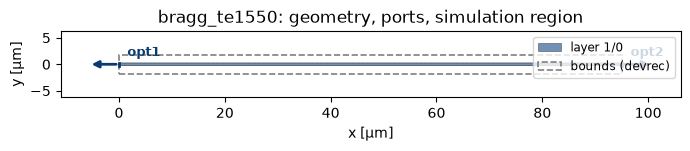

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd import SimulationSpec, Technology, get_solver
from gds_fdtd.lyprocessor import load_cell
from gds_fdtd.plotting import component_outlines, plot_component, plot_field, plot_monitor_planes
from gds_fdtd.simprocessor import load_component_from_tech
from gds_fdtd.smatrix import SMatrix


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


REC = _find("examples/11_bragg_grating/recorded")

tech = Technology.from_yaml(_find("examples/tech.yaml"))
cell, layout = load_cell(str(_find("examples/devices.gds")), top_cell="bragg_te1550")
comp = load_component_from_tech(cell=cell, tech=tech)
print(f"{comp.name}: {comp.bounds.x_span:.1f} x {comp.bounds.y_span:.1f} um, "
      f"ports {[p.name for p in comp.ports]}")

plot_component(comp)
plt.show()

At full scale the grating looks like a plain strip — the corrugation is tens
of nanometers on a 95 µm device. Zoom in on a few microns and the periodic
teeth appear:

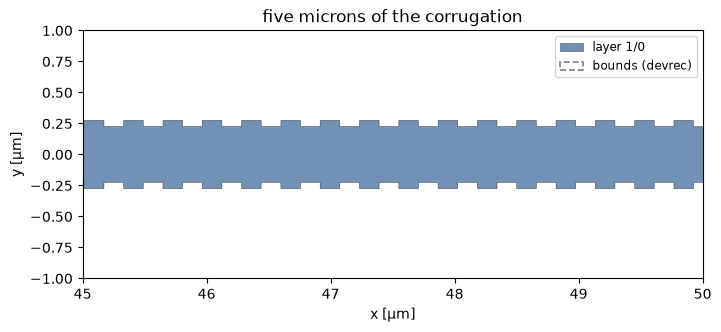

In [2]:
fig, ax = plot_component(comp)
ax.set_xlim(45, 50)
ax.set_ylim(-1.0, 1.0)
ax.set_title("five microns of the corrugation")
plt.show()

## 1 · One spec: a fine spectrum, a frugal field monitor

Resolving a stopband needs a dense wavelength grid — 101 points across
1.50–1.60 µm here. Recording the **field** at all 101 points would multiply
the download for nothing, so the monitor is told to keep five wavelengths:
two guesses inside the expected stopband and neighbors outside it. The
z-plane is pinned to the middle of the silicon core:

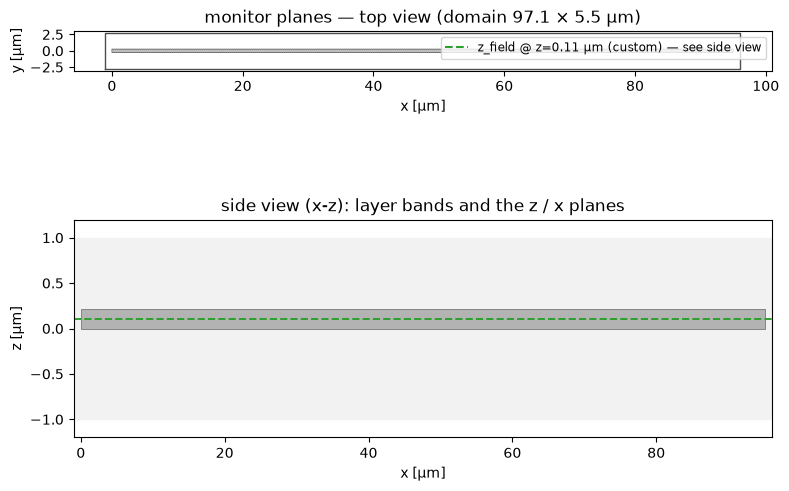

In [3]:
spec = SimulationSpec(
    wavelength_start=1.5, wavelength_end=1.6, wavelength_points=101,
    mesh=10, z_min=-1.0, z_max=1.0,
    field_monitors=("z",),
    field_monitor_positions={"z": 0.11},
    field_monitor_wavelengths=(1.51, 1.545, 1.55, 1.555, 1.59),
)
solver = get_solver("tidy3d")(comp, technology=tech, spec=spec)
plot_monitor_planes(solver)
plt.show()

## 2 · The spectrum

The run executed on tidy3d (2 excitations, ~0.4 FC; artifacts in
`recorded/`, see `PROVENANCE.md`). Transmission collapses inside the
stopband while reflection rises to ~0 dB — a distributed mirror:

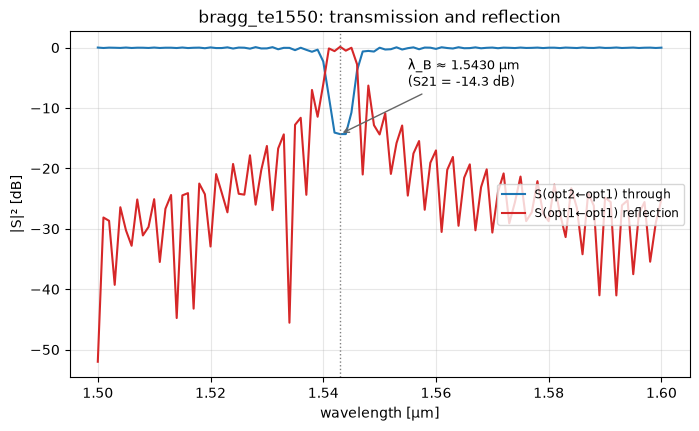

stopband center ≈ 1.5430 um; width (S21 < -10 dB) ≈ 3.0 nm


In [4]:
sm = SMatrix.from_npz(REC / "bragg_tidy3d.npz")
p_in, p_out = sm.port_names[0], sm.port_names[1]
wl = sm.wavelength_um
s21 = 10 * np.log10(np.abs(sm.sel(p_out, p_in, 1, 1)) ** 2)
s11 = 10 * np.log10(np.abs(sm.sel(p_in, p_in, 1, 1)) ** 2)

order = np.argsort(wl)
wl, s21, s11 = wl[order], s21[order], s11[order]
i_min = int(np.argmin(s21))
lam_bragg = wl[i_min]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(wl, s21, label=f"S({p_out}←{p_in}) through", color="tab:blue")
ax.plot(wl, s11, label=f"S({p_in}←{p_in}) reflection", color="tab:red")
ax.axvline(lam_bragg, color="0.5", ls=":", lw=1)
ax.annotate(f"λ_B ≈ {lam_bragg:.4f} µm\n(S21 = {s21[i_min]:.1f} dB)",
            xy=(lam_bragg, s21[i_min]), xytext=(lam_bragg + 0.012, s21[i_min] + 8),
            arrowprops={"arrowstyle": "->", "color": "0.4"}, fontsize=9)
ax.set_xlabel("wavelength [µm]")
ax.set_ylabel("|S|² [dB]")
ax.set_title(f"{comp.name}: transmission and reflection")
ax.legend(loc="center right", fontsize="small")
ax.grid(alpha=0.3)
plt.show()

in_band = float(wl[i_min])
below = s21 < -10
if below.any():
    bw_nm = 1000 * (wl[below].max() - wl[below].min())
    print(f"stopband center ≈ {in_band:.4f} um; width (S21 < -10 dB) ≈ {bw_nm:.1f} nm")

## 3 · The same monitor, in and out of the stopband

The recorded field file carries all five wavelengths; picking the one nearest
the measured stopband center against a far-out-of-band neighbor shows the
mirror at work. In-band, the field decays *into* the grating — the input
side carries a standing-wave ripple where the injected and reflected waves
interfere, and almost nothing reaches the output. Out-of-band, the envelope
runs flat through all 95 µm:

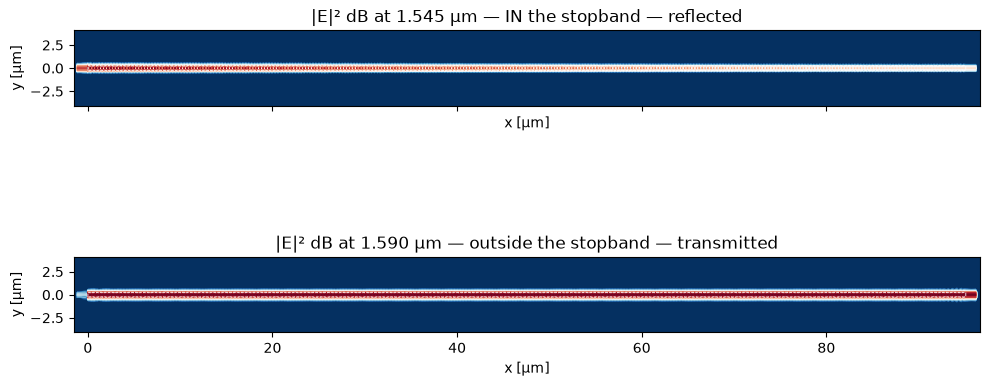

In [5]:
fz = np.load(REC / "bragg_field_z.npz")
wls = np.asarray(fz["wavelength_um"])
i_in = int(np.argmin(np.abs(wls - in_band)))
i_out = int(np.argmax(np.abs(wls - in_band)))
outlines = component_outlines(comp, axis="z")

fig, axs = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, idx, tag in (
    (axs[0], i_in, "IN the stopband — reflected"),
    (axs[1], i_out, "outside the stopband — transmitted"),
):
    plot_field(
        fz["mag2"][idx], x=fz["h"], y=fz["v"], scale="db",
        ax=ax, outline=outlines, colorbar=False,
        title=f"|E|² dB at {wls[idx]:.3f} µm — {tag}",
    )
fig.tight_layout()
plt.show()

## 4 · Sanity: energy has to go somewhere

In a lossless reflector, in-band light that does not transmit must reflect.
|S11|² + |S21|² stays near one across the band. The dips at the stopband
edges are real radiation from the corrugation; the slight overshoot above
one at the reflection peak is mesh-10 discretization error (the same
few-percent passivity slack the beamz end-to-end test documents) — a finer
mesh pulls it in at proportionally higher cost:

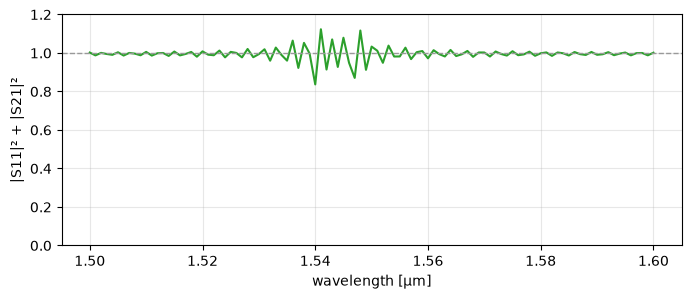

power balance: min 0.837, max 1.123


In [6]:
balance = 10 ** (s11 / 10) + 10 ** (s21 / 10)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(wl, balance, color="tab:green")
ax.axhline(1.0, color="0.6", ls="--", lw=1)
ax.set_xlabel("wavelength [µm]")
ax.set_ylabel("|S11|² + |S21|²")
ax.set_ylim(0, 1.2)
ax.grid(alpha=0.3)
plt.show()
print(f"power balance: min {balance.min():.3f}, max {balance.max():.3f}")

## Recap

- `bragg_te1550` from `devices.gds`, straight from GDS to a tidy3d run with
  the shared technology file — nothing device-specific in the setup.
- One simulation produced the full 101-point spectrum **and** the field at
  five chosen wavelengths (`spec.field_monitor_wavelengths`), pinned to the
  silicon core (`spec.field_monitor_positions`).
- The spectrum finds the stopband; the field pictures show *why*: in-band
  the grating is a mirror (decay + standing wave), out-of-band it is just a
  waveguide.